# 02 · EDA & RFM Analysis

**Notebook:** 02 

**Goal:** Build the RFM table from clean transactions, inspect its distributions, and perform deep bivariate & multivariate analysis.

### What this notebook covers
- Build customer-level RFM table (Recency, Frequency, Monetary + extras)
- Univariate inspection of all RFM columns with outlier detection
- Yeo-Johnson skewness validation on Monetary & Frequency
- Bivariate / multivariate analysis (4 RFM-based + 5 transaction-based insights)
- Final business recommendations

In [34]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

In [35]:
# for plotly visualizations in SVG format for github
import plotly.io as pio
pio.renderers.default = 'svg'

In [36]:
# ── Load clean transactions from notebook 01 ─────────────────────────────────
df = pd.read_csv('/Users/mohammedmahmood/Documents/Data projects/Projects/Data science/Unsupervised proj/Online Retail Customer Segmentation RFM Analysis/data/2_clean_transactions.csv' )
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,invoice_weekday,invoice_month,invoice_year,invoice_hour,Total_Price
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Tuesday,12,2009,7,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Tuesday,12,2009,7,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Tuesday,12,2009,7,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,Tuesday,12,2009,7,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Tuesday,12,2009,7,30.0


# **RFM creation**

- Create complete RFM table with all customer-level columns  
- Perform bivariate + multivariate analysis  
- Select the best / most relevant features for clustering

In [37]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'CustomerID', 'Country', 'invoice_weekday', 'invoice_month',
       'invoice_year', 'invoice_hour', 'Total_Price'],
      dtype='object')

In [38]:
df.InvoiceDate.dtype

dtype('O')

In [39]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [40]:
# convert InvoiceDate to datetime to can be used to calculate recency
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# create reference date for recency
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)


## **create RFM table**

In [41]:
rfm = (
    df
    .groupby("CustomerID")
    .agg(
        FirstPurchase=("InvoiceDate", "min"),
        LastPurchase=("InvoiceDate", "max"),

        Frequency=("Invoice", "nunique"),
        Monetary=("Total_Price", "sum"),

        TotalQuantity=("Quantity", "sum"),
        UniqueProducts=("StockCode", "nunique"),
    )
    .reset_index()
)


### **1. Recency:**
- how recently a customer has made a purchase or interacted with your business

In [42]:
rfm["Recency"] = (
    reference_date - rfm["LastPurchase"]
).dt.days


### **2. CustomerLifetime**
- how long a customer has been active with the business, measured in days.

In [43]:
rfm["CustomerLifetime"] = (
    rfm["LastPurchase"] - rfm["FirstPurchase"]
).dt.days


### **3. AvgOrderValue**
measures the average revenue generated from each purchase made by a customer. It helps identify customers who place larger orders

In [44]:
rfm["AvgOrderValue"] = (
    rfm["Monetary"] / rfm["Frequency"]
)


In [45]:
rfm

,CustomerID,FirstPurchase,LastPurchase,Frequency,Monetary,TotalQuantity,UniqueProducts,Recency,CustomerLifetime,AvgOrderValue
0,12346.0,2009-12-14 08:34:00,2011-01-18 10:01:00,12,77556.46,74285,27,326,400,6463.038333
1,12347.0,2010-10-31 14:20:00,2011-12-07 15:52:00,8,4921.53,2967,126,2,402,615.191250
2,12348.0,2010-09-27 14:59:00,2011-09-25 13:13:00,5,2019.40,2714,25,75,362,403.880000
3,12349.0,2010-04-29 13:20:00,2011-11-21 09:51:00,4,4428.69,1624,138,19,570,1107.172500
4,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,197,17,310,0,334.400000
...,...,...,...,...,...,...,...,...,...,...
5873,18283.0,2010-02-19 17:16:00,2011-12-06 12:02:00,22,2664.90,1679,352,4,654,121.131818
5874,18284.0,2010-10-04 11:33:00,2010-10-04 11:33:00,1,461.68,494,28,432,0,461.680000
5875,18285.0,2010-02-17 10:24:00,2010-02-17 10:24:00,1,427.00,145,12,661,0,427.000000
5876,18286.0,2009-12-16 10:45:00,2010-08-20 11:57:00,2,1296.43,608,67,477,247,648.215000


## **univarite for RFM Columns to see distributions and outliers**

In [46]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        5878 non-null   float64       
 1   FirstPurchase     5878 non-null   datetime64[ns]
 2   LastPurchase      5878 non-null   datetime64[ns]
 3   Frequency         5878 non-null   int64         
 4   Monetary          5878 non-null   float64       
 5   TotalQuantity     5878 non-null   int64         
 6   UniqueProducts    5878 non-null   int64         
 7   Recency           5878 non-null   int64         
 8   CustomerLifetime  5878 non-null   int64         
 9   AvgOrderValue     5878 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(5)
memory usage: 459.3 KB


In [47]:
# drop unnecessary columns in analysis
rfm.drop(columns= ["FirstPurchase", "LastPurchase"], inplace= True, axis= 1)

In [48]:
df.drop_duplicates(inplace= True)
df.reset_index(inplace= True, drop= True)

In [49]:
rfm["TotalQuantity"] = rfm["TotalQuantity"].astype(int)

In [50]:
# convert column to float with two decimal places
cols = ["Monetary"]

rfm[cols] = (
    rfm[cols]
    .astype(float)
    .round(2)
)


# Univariate Analysis on RFM Columns to:
- Identify outliers
- Examine distributions
- Detect any problems if they exist
- Prepare the data for analysis and modeling

### **Frequency**

In [51]:
rfm.Frequency.describe()

count    5878.000000
mean        6.289384
std        13.009406
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       398.000000
Name: Frequency, dtype: float64

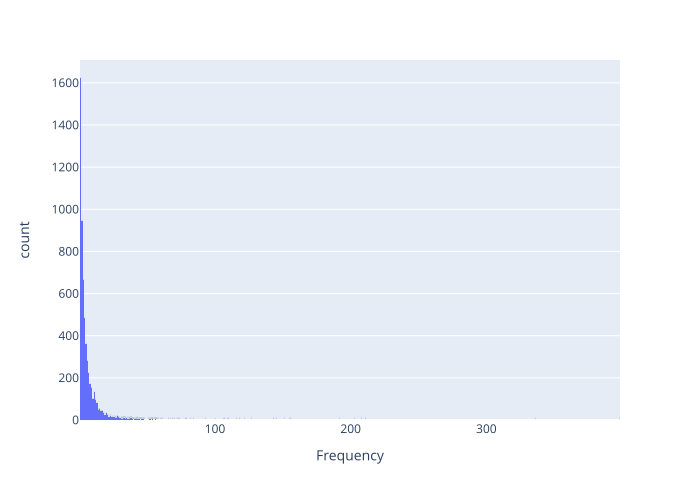

In [52]:
px.histogram(rfm, x="Frequency", text_auto=True)

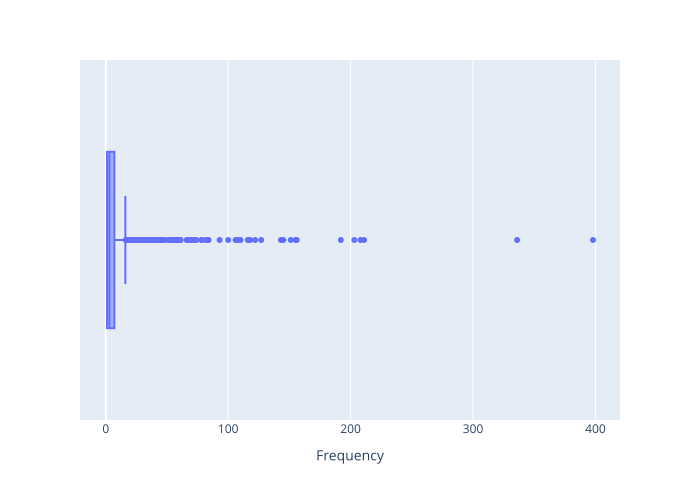

In [53]:
px.box(rfm, x="Frequency")

In [54]:
rfm[rfm["Frequency"] == 201]

,CustomerID,Frequency,Monetary,TotalQuantity,UniqueProducts,Recency,CustomerLifetime,AvgOrderValue


In [55]:
rfm[rfm["Frequency"] == 209]

,CustomerID,Frequency,Monetary,TotalQuantity,UniqueProducts,Recency,CustomerLifetime,AvgOrderValue


In [56]:
from datasist.structdata import detect_outliers

idx = detect_outliers(rfm, 0 , ['Frequency'])
len(idx )


427

### **Monetary**

In [57]:
rfm.Monetary.describe()

count      5878.000000
mean       2955.904092
std       14440.852686
min           2.950000
25%         342.280000
50%         867.740000
75%        2248.305000
max      580987.040000
Name: Monetary, dtype: float64

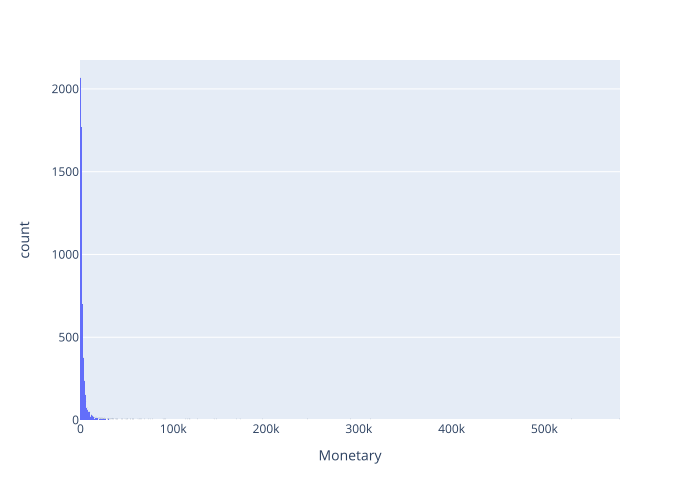

In [58]:
px.histogram(rfm, x="Monetary", text_auto=True)

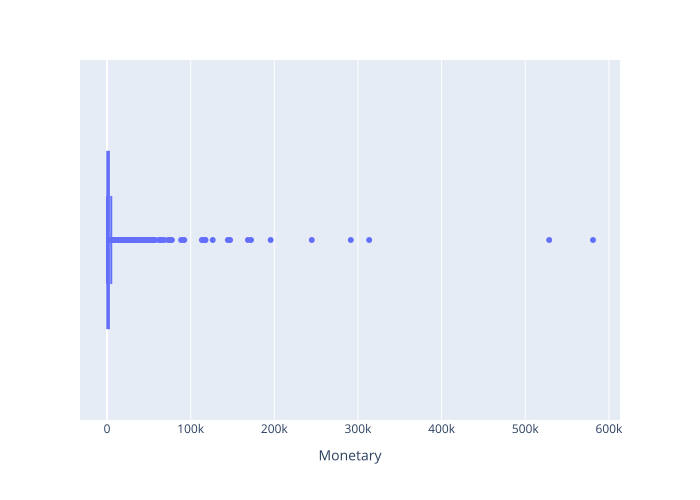

In [59]:
px.box(rfm, x="Monetary")

In [60]:
rfm[rfm["Monetary"] == 280206.020000]

,CustomerID,Frequency,Monetary,TotalQuantity,UniqueProducts,Recency,CustomerLifetime,AvgOrderValue


In [61]:
from datasist.structdata import detect_outliers

idx = detect_outliers(rfm, 0 , ['Monetary'])
len(idx )

633

### **Recency**

In [62]:
rfm.Recency.describe()

count    5878.000000
mean      201.331916
std       209.338707
min         1.000000
25%        26.000000
50%        96.000000
75%       380.000000
max       739.000000
Name: Recency, dtype: float64

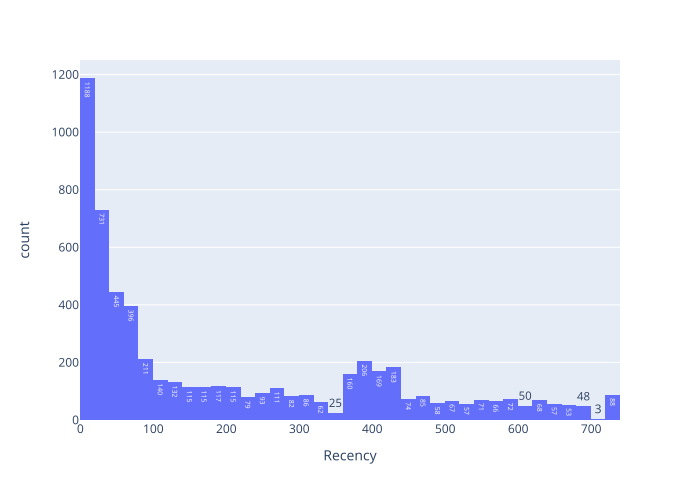

In [63]:
px.histogram(rfm, x="Recency", text_auto=True)

In [64]:
from datasist.structdata import detect_outliers

idx = detect_outliers(rfm, 0 , ['Recency'])
len(idx )

0

## **Handling Skewness and Outliers in RFM Features**

Observations:
- All three main RFM columns (**Recency**, **Frequency**, **Monetary**) show strong **right-skewness**.

Decisions:
1. **Outliers will not be removed**  
   → These high-value customers represent important and real behavioral patterns (e.g., VIP/whale customers) that should be preserved for meaningful segmentation.

2. **Skewness and outlier impact will be handled using the Yeo-Johnson transformation**  
   → This will be applied inside the ML pipeline during the preprocessing/modeling step

3. ***Validation approach***  
   - Create a copy of the RFM table  
   - Apply Yeo-Johnson transformation manually on this copy  
   - Compare distributions (before vs. after) using histograms
   - Evaluate whether the transformation improves symmetry and reduces outlier influence before integrating it into the pipeline.

### **Validation approach**

In [65]:
from sklearn.preprocessing import PowerTransformer

# Columns to transform
cols = ['Monetary', 'Frequency']

# Copy original df to keep original values
rfm_transformed = rfm.copy()


In [66]:
# Initialize PowerTransformer
pt = PowerTransformer(method='yeo-johnson')

# Fit & transform
rfm_transformed[cols] = pt.fit_transform(rfm[cols])


In [67]:
rfm_transformed['Monetary_YJ'] = pt.fit_transform(rfm[['Monetary']])
rfm_transformed['Frequency_YJ'] = pt.fit_transform(rfm[['Frequency']])

In [68]:
# Compare skew before & after
print("Original skew:")
print(rfm[['Monetary', 'Frequency']].skew())

print("\nTransformed skew:")
print(rfm_transformed[['Monetary_YJ', 'Frequency_YJ']].skew())


Original skew:
Monetary     25.070190
Frequency    12.639951
dtype: float64

Transformed skew:
Monetary_YJ    -0.007478
Frequency_YJ    0.164312
dtype: float64


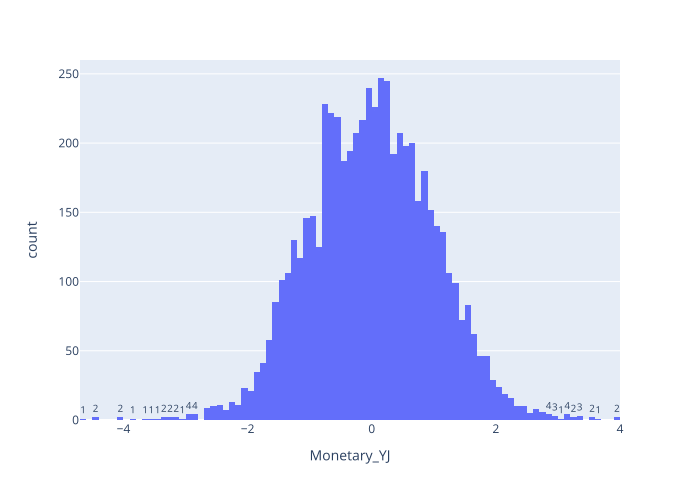

In [69]:
px.histogram(rfm_transformed, x="Monetary_YJ", text_auto=True)

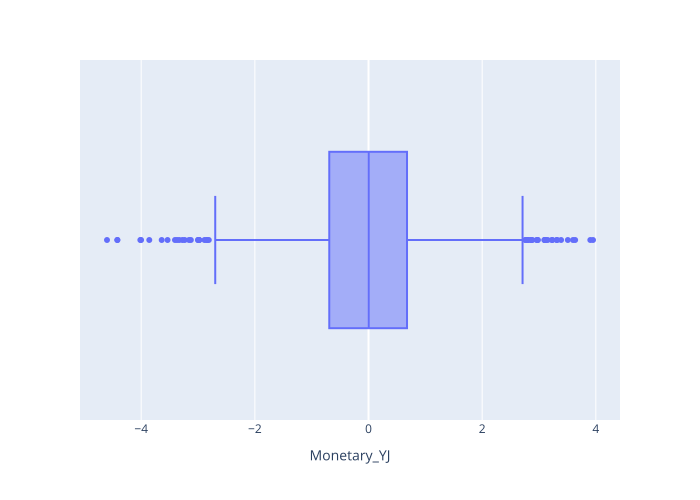

In [70]:
px.box(rfm_transformed, x="Monetary_YJ")

In [71]:
from datasist.structdata import detect_outliers

idx = detect_outliers(rfm_transformed, 0 , ['Monetary_YJ'])
len(idx)

50

#  Final Decision on Skewness Handling and outliers

- Yeo-Johnson transformation results look very good  
- → Will apply Yeo-Johnson to handle skewness in all RFM features  
- → Integrate into ML pipeline (preprocessing step)

Outliers → **keep** (needed to identify VIP customers)  
- Skewness → handle with **Yeo-Johnson** (reduces outlier impact + improves symmetry)  

# - **Analysis before clustring**


**We will do some important analysis first**

Using:
- RFM table
- Original transactional data (every single order)

**Main goals:**
- Understand customers better
- Find strong patterns
- Get useful business insights
- Help us choose best features → clustering


## **1- Analysis using RFM table**

In [72]:
rfm_analysis = rfm.copy()

In [73]:
# rename columns to make names understandable
rfm_analysis.rename(columns={
    "Frequency": "Number_of_Orders",
    "Monetary": "Total_Spend",

    "TotalQuantity": "Total_Items_Purchased",
    "UniqueProducts": "Product_Diversity",
    "Recency": "Days_Since_Last_Purchase",

    "CustomerLifetime": "Customer_Lifetime_Days",
    "AvgOrderValue": "Average_Order_Value"
}, inplace=True)


In [74]:
rfm_analysis.columns

Index(['CustomerID', 'Number_of_Orders', 'Total_Spend',
       'Total_Items_Purchased', 'Product_Diversity',
       'Days_Since_Last_Purchase', 'Customer_Lifetime_Days',
       'Average_Order_Value'],
      dtype='object')

### 1.  **Do customers who place more orders spend more money overall**

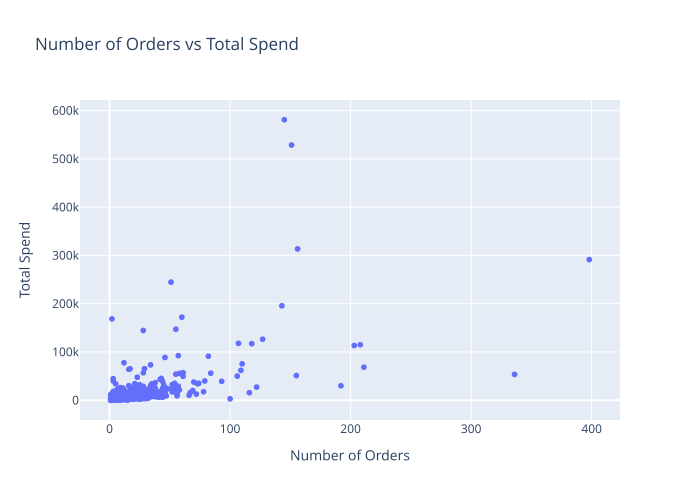

In [75]:
fig = px.scatter(
    rfm_analysis,
    x="Number_of_Orders",
    y="Total_Spend",
    title="Number of Orders vs Total Spend",
    labels={
        "Number_of_Orders": "Number of Orders",
        "Total_Spend": "Total Spend"
    }
)

fig.show()

##### **1. Customers who order more often spend dramatically more in total — the pattern is very strong and almost linear in the upper range.**

##### **2. The majority of customers order very few times (mostly 1–10 orders) → they contribute only a small portion of revenue (typically under 20–50k EGP lifetime).**

##### **3. A small group of high-frequency customers (30–200+ orders) generates the lion’s share of total spend — many in the 50k–250k+ range.**

### **2. Do customers who buy more product types spend more?**

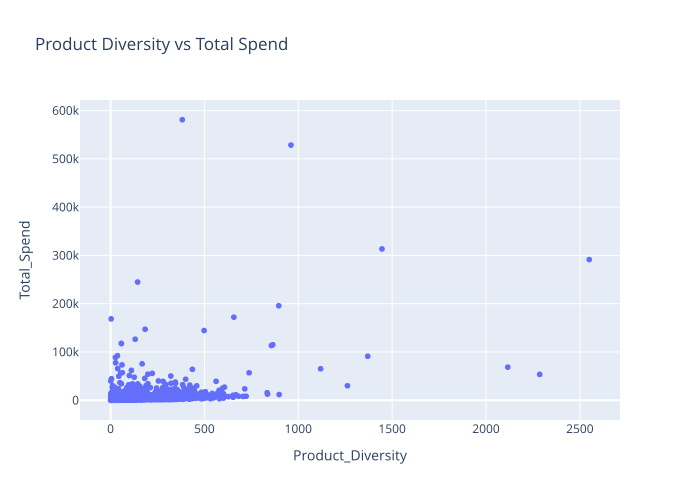

In [76]:
fig = px.scatter(
    rfm_analysis,
    x="Product_Diversity",
    y="Total_Spend",
    title="Product Diversity vs Total Spend"
)

fig.show()


##### **1. Customers who buy a wider variety of product types (higher Product Diversity) tend to spend significantly more in total — the link is clear and positive.**


##### **2. As diversity increases beyond ~200–400 types, total spend starts to rise noticeably.**

##### **3. Very few high-spend customers exist among those who only buy a narrow range of items.**


#### **-summary**

##### **Customers who explore and buy from many different product categories are dramatically more valuable — variety is a powerful predictor of high lifetime spend.**

### **3. Do long-term customers always generate more revenue?**

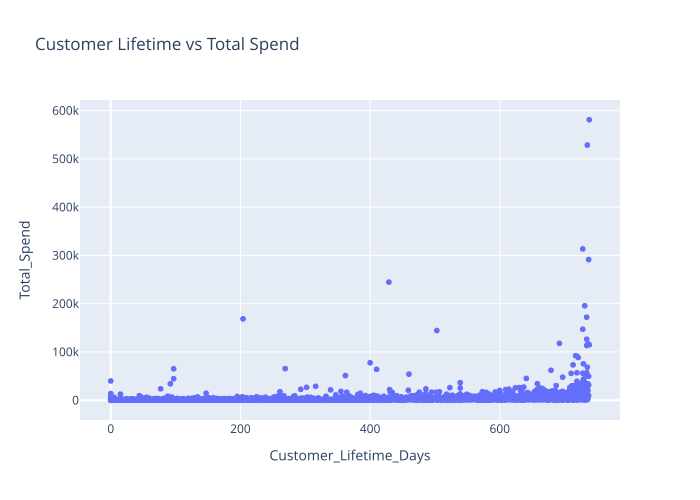

In [77]:
fig = px.scatter(
    rfm_analysis,
    x="Customer_Lifetime_Days",
    y="Total_Spend",
    trendline="ols",
    title="Customer Lifetime vs Total Spend"
)

fig.show()

##### **1. Customers with short lifetime (0–100 days) mostly have low total spend (almost all under 10–20k).**

##### **2. The highest spenders (100k–250k+) are almost all in the longer-lifetime group (250–350+ days).**

**- However**:

***many long-term customers still spend very little — the chart shows a huge cluster of low-spend people even at 300–350 days.***

#### **-summary**

##### **Longer customer relationships open the door to much higher revenue, but not every long-term customer walks through it**


### **4. Do customers who buy in bulk spend more or just buy cheap items?**

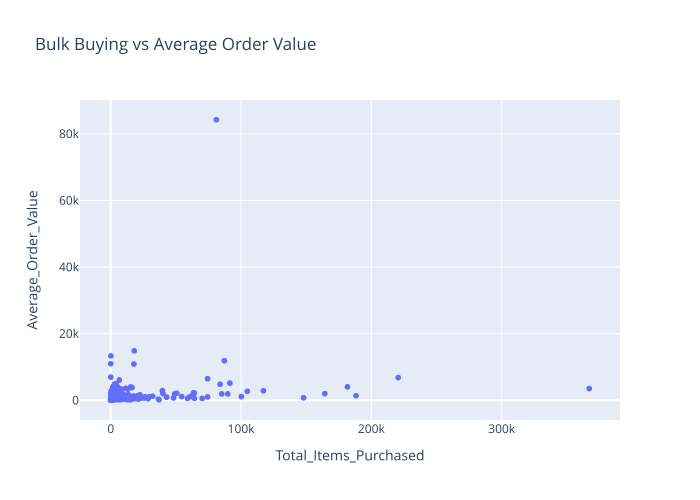

In [78]:
fig = px.scatter(
    rfm_analysis,
    x="Total_Items_Purchased",
    y="Average_Order_Value",
    title="Bulk Buying vs Average Order Value"
)

fig.show()


**1. Customers who buy in bulk (high Total Items Purchased) do not necessarily spend more per order — in fact, the opposite is more common.**

**2. The vast majority of bulk buyers (high total items) have very low average order value (most under 5–10k per order).**

**3 .They tend to buy large quantities of cheaper items rather than expensive ones.**

High average order value (20k–90k per order) almost only appears among customers with low-to-moderate total items (mostly under 20–50k total items purchased).


#### **- Summary**

**1. bulk buyers are typically volume-driven (lots of low-price items), not value-driven (fewer expensive items).**

**2. Bulk buyers usually buy lots of cheap items rather than expensive ones — high average order value comes from customers who buy fewer, higher-priced products.”**

## **2- Analysis using original data (for Insights can't covered using RFM Table )**

### **5. Which products drive most revenue?**

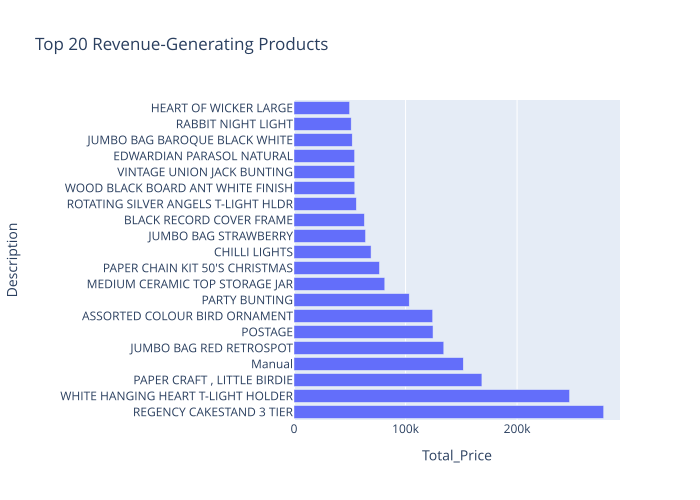

In [79]:
top_products = (

    df.groupby(["StockCode", "Description"])["Total_Price"]

      .sum()
      .reset_index()
      .sort_values("Total_Price", ascending=False)
      .head(20)

)

fig = px.bar(
    top_products,
    x="Total_Price",
    y="Description",
    orientation="h",
    title="Top 20 Revenue-Generating Products"
)

fig.show()



**The absolute #1 product by far is REGENCY CAKESTAND 3 TIER → generates over 120k in total revenue (clearly the standout winner).**

**The next strongest performers are in the 60–100k range:**

- WHITE HANGING HEART T-LIGHT HOLDER

- JUMBO BAG RED RETROSPOT

- MEDIUM CERAMIC TOP STORAGE JAR

- POSTAGE (likely shipping fees, but still counts as revenue driver)
PARTY BUNTING


###### **- Summray**

**Our revenue is driven by a tiny group of hero products — the Regency Cakestand 3 Tier alone generates far more than most others, so let’s double down on stocking, promoting, and never running out of these top performers**

In [80]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'CustomerID', 'Country', 'invoice_weekday', 'invoice_month',
       'invoice_year', 'invoice_hour', 'Total_Price'],
      dtype='object')

### **6. Which countries generate high revenue but low order volum?**

In [81]:
country_summary = (
    df.groupby("Country")
      .agg(
          Total_Revenue=("Total_Price", "sum")
      )
      .reset_index()
      .sort_values(by="Total_Revenue", ascending=False)
)


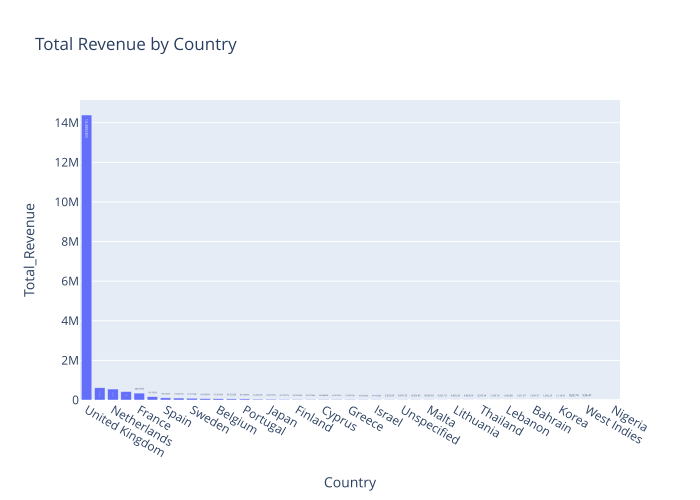

,Country,Total_Revenue
38,United Kingdom,1.438923e+07
10,EIRE,6.165705e+05
24,Netherlands,5.540381e+05
14,Germany,4.250197e+05
13,France,3.487690e+05
0,Australia,1.692835e+05
32,Spain,1.083325e+05
34,Switzerland,1.000619e+05
33,Sweden,9.151582e+04
9,Denmark,6.858069e+04


In [82]:
fig = px.bar(
    country_summary,
    x="Country",
    y="Total_Revenue",
    text_auto=True,
    title="Total Revenue by Country"
)

fig.show()
country_summary.head(10)


**1. Revenue is extremely concentrated in just a few countries — the top 3–5 dominate almost everything.**

**2. United Kingdom is the clear #1 by far → generates over 6 million in total revenue (about 60–70%+ of everything shown).**

**3. Many countries (especially outside Europe) have very low or almost zero contribution → e.g., Saudi Arabia, Bahrain, Brazil, Lebanon, USA, Canada are tiny in comparison.**


#### **- summary:**

**Our revenue is overwhelmingly driven by the United Kingdom and a handful of European markets — the UK alone accounts for most of our total, so protecting and growing that core market is priority**




### **7.Which months are the strongest for sales?**

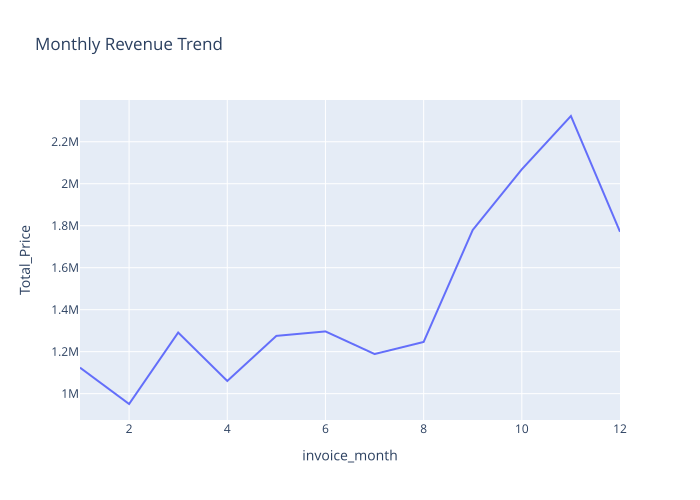

In [83]:
month_revenue = (
    df.groupby( ["invoice_month"] )["Total_Price"]
      .sum()
      .reset_index()
)

fig = px.line(
    month_revenue,
    x="invoice_month",
    y="Total_Price",
    title="Monthly Revenue Trend"
)

fig.show()


- **Sales show clear seasonal peaks and dips across the year, with two standout strong months.**

**The absolute strongest month is month 10 (October) → highest revenue at around 1M+ (peak of the year).**

**Month 9 (September) is also very strong → close second with ~0.95M.
Another solid peak in month 5–6 (May–June) → around 0.68–0.7M, showing a mid-year lift.**

**The weakest months are month 4 (April) and especially month 11 (November) → sharp drops to ~0.45–0.5M.**


#### **- summary:**

Our strongest sales months are October and September — we see a big Q4 surge, so let's front-load marketing and stock up early to capture the holiday momentum and avoid the November dip.”

### **8. Which days of the week generate the highest revenue?**

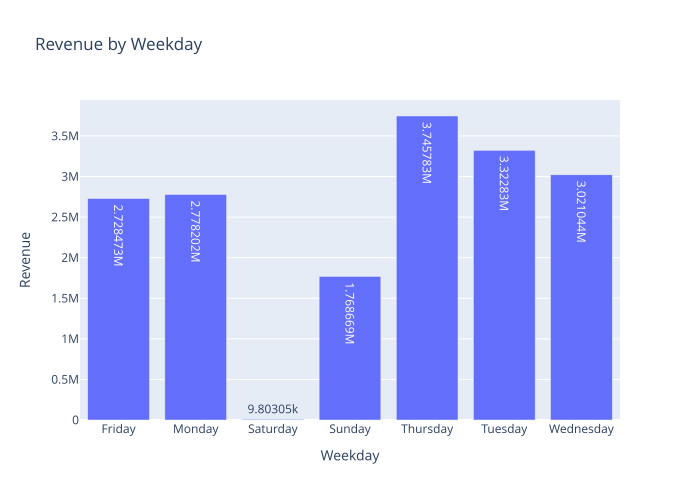

In [84]:
weekday_revenue = (
    df.groupby("invoice_weekday")["Total_Price"]
      .sum()
      .reset_index()
)

fig = px.bar(
    weekday_revenue,
    x="invoice_weekday",
    y="Total_Price",
    title="Revenue by Weekday",
    text_auto=True,
    labels={"invoice_weekday": "Weekday", "Total_Price": "Revenue"}

)

fig.show()

**Thursday is our strongest revenue day by a clear margin, followed by Tuesday and Wednesday — mid-week is when customers spend the most, while Sundays are consistently the slowest.”**

### **9. What hours generate most revenue?**

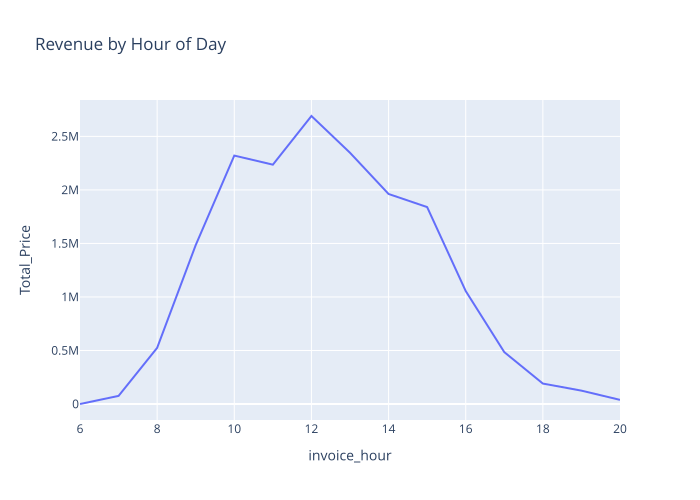

In [85]:
hourly_revenue = (
    df.groupby("invoice_hour")["Total_Price"]
      .sum()
      .reset_index()
)

import plotly.express as px

fig = px.line(
    hourly_revenue,
    x="invoice_hour",
    y="Total_Price",
    title="Revenue by Hour of Day"
)

fig.show()


#### **Revenue shows a clear daily rhythm with a strong peak in the late morning to early afternoon.**

**1. The highest revenue comes between 10:00 and 12:00 (hours 10–12) → this is the absolute peak, reaching around 1.2M at hour 12.**

**2. Strong build-up starts from 8:00–10:00 → revenue rises quickly and sharply.**

**3. After the midday peak (around noon), revenue steadily declines through the afternoon and evening → drops significantly after 14:00–16:00 and becomes very low from 18:00 onward.**

# **Final Summary & Business Recommendations**

### Executive Summary
Our customer base follows classic **80/20** behavior very strongly:

- A small group of **frequent, long-term, variety-seeking customers** generates the majority of revenue.
- **United Kingdom** dominates total revenue (≈60–70%), followed by a few European countries.
- Strong **seasonal peaks** in September–October (holiday / Q4 shopping).
- **Mid-week** (especially Thursday) and **late morning to early afternoon** (10:00–12:00) bring the highest sales.
- Top revenue products are mostly **affordable home decor, kitchen items, party supplies, and decorative lights** — Regency Cakestand 3 Tier is the clear #1 hero product.

## Key Insights – Core Patterns

1. **Frequency Drives Revenue**  
   More orders = dramatically higher total spend.  
   Repeat buyers (30+ orders) are our real high-value customers.

2. **Product Variety = Higher Value**  
   Customers who buy many different product types spend significantly more.  
   Variety seekers are much more valuable than single-category buyers.

3. **Long Lifetime Helps — But Not Automatic**  
   Longer relationships increase the chance of high spend, but many long-term customers stay low-value.

4. **Bulk Buyers vs High-Ticket Buyers**  
   Bulk buyers usually buy lots of cheap items → low average order value.  
   High average order value comes from customers buying fewer, more expensive items.

5. **Geographic Concentration**  
   United Kingdom is responsible for most revenue.  
   After top 5 European countries, contribution drops very sharply.

6. **Seasonal & Time Patterns**  
   - Strongest months: **October > September** (Q4 holiday surge)  
   - Strongest weekday: **Thursday** (mid-week peak)  
   - Strongest hours: **10:00–12:00** (working hours / lunch time)

7. **Hero Products**  
   Revenue is driven by a very small number of top-selling items (Regency Cakestand 3 Tier, White Hanging Heart T-Light Holder, Jumbo Bags, Party Bunting, etc.).

## Strategic Recommendations

### 1. Protect & Grow Repeat & High-Value Customers
- Build strong **loyalty & repeat-purchase programs** for customers who already ordered 5–20+ times.
- Give special treatment to **high-frequency + high-variety** customers (personal offers, early access, VIP events).
- Create a **VIP / Whale** segment (top 1–5% spenders) with dedicated care (account managers, exclusive deals).

### 2. Focus Marketing & Inventory on Peak Times
- Increase ad budget, promotions, email & push notifications during **September–October**, **Thursday**, and **10:00–12:00**.
- Plan inventory and staffing around **Q4 surge** — avoid stockouts of hero products in peak months.
- Reduce spend on low-performance times (Sunday, evenings, November lull).

### 3. Double Down on Hero Products & Categories
- Always keep **top 10–15 products** in stock — especially Regency Cakestand, Jumbo Bags, Party Bunting, lights, and kitchen/party items.
- Create **product bundles** and **cross-sell recommendations** around these winners.
- Promote **variety** — encourage customers to try new categories (e.g., "customers also bought…" featuring top sellers).

### 4. Geographic Focus
- **Protect and grow the UK market** — this is our main engine.
- Invest carefully in next-strongest markets (Netherlands, Ireland, Germany, France).
- Treat non-European countries as experimental — low priority until they show real growth.

### 5. Product & Customer Strategy
- Push **high-ticket items** to increase average order value.
- Use **retargeting & reminders** to turn one-time / low-frequency buyers into repeat customers.
- Analyze why many long-term customers stay low-value — maybe offer incentives to explore more categories.

**One-liner takeaway for leadership**  
“Our biggest revenue comes from repeat UK customers who buy many different items during mid-week in Q4 — let’s protect the heroes, time our promotions perfectly, and turn more people into frequent, high-value buyers.”


In [86]:
rfm_analysis.drop_duplicates(inplace= True)
rfm_analysis.reset_index(inplace= True, drop= True)

In [87]:
# # ── Save RFM analysis table to use in streamlit app ────────────────────────────────────

# rfm_analysis.to_csv("3_rfm_for_analysis.csv", index=False)